In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import tifffile as tiff
import os
import sys
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

In [2]:
img_name = '20260717T120225_pA_Activin_D4_48hr_W0013'
channel_names = ['Sox17', 'Activin', 'FoxA2', 'Hoechst']
if_cols = [c + '_mean' for c in channel_names if c != 'Hoechst']

cell_df = pd.read_parquet(f'../data/stitched/{img_name}_features.parquet')
out = tiff.imread(f'../data/stitched/{img_name}.tif')
fig_dir = f'../results/figures/{img_name}'
os.makedirs(fig_dir, exist_ok=True)
print(cell_df.shape)

(9068, 22)


### Ablation: how much does each marker actually matter?

`features.ipynb` trains one GNN/GAT with a fixed `global_x_cols`/`neighbor_x_cols`
split and reports its test R^2, which tells you how well the model predicts, but not
which of its inputs are doing the work. This notebook retrains the SAME model, once
per input column removed, and compares test R^2 against the full model -- the drop in
R^2 when a column is missing IS that column's contribution.

Both input blocks get ablated, since they play different roles:
- **`neighbor_x_cols`**: a marker seen only through the SURROUNDING cells (never the
  center cell's own value) -- removing one asks "how much does neighbor-X specifically
  contribute to predicting the center cell's other markers?"
- **`global_x_cols`**: a marker (or `local_density`) seen directly for the cell
  ITSELF -- removing one asks "how much does the cell's own X help predict its OTHER
  markers, on top of whatever its neighbors already say?"

`y_cols` is held FIXED across every ablation variant (not re-derived per config), so
every comparison is apples-to-apples against the same prediction targets. R^2 is
reported in original (raw fluorescence) units throughout, consistent with
`features.ipynb`/`cross_predict.ipynb`.

`EPOCHS` defaults lower here than `features.ipynb`'s final 1000-1500, since this
notebook trains one full model PER ablation config (6 configs below) -- raise it once
you've confirmed the sweep runs end-to-end.

In [3]:
from tools.morphology import split_indices, indices_to_mask, r2_table, plot_experiment_comparison, plot_feature_importance_by_target, local_density
from models.gnn import build_prediction_data, train_neighbor_predictor, NeighborIFPredictor, predict_df, border_mask
from models.gat import NeighborIFPredictorGAT

PRED_RADIUS = 50  # px -- same radius graph as features.ipynb, NOT k-NN
MODEL_TYPE = 'gnn'  # 'gnn' | 'gat' -- which architecture to sweep (GAT is slower per config)
SCALING = 'log1p_standard'  # see models.gnn.ColumnScaler
EPOCHS = 700  # smaller than features.ipynb's final run -- see markdown above
SEED = 0

N = len(cell_df)
centroids = cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)
cell_df['local_density'] = local_density(centroids, radius=PRED_RADIUS)

# Same border exclusion + split as features.ipynb, computed once and reused for every
# ablation config, so configs differ ONLY in which input columns they see.
is_border = border_mask(centroids, out.shape[1:], PRED_RADIUS)
valid_target_idx = np.where(~is_border)[0]
train_pos, val_pos, test_pos = split_indices(len(valid_target_idx), val_frac=0.15, test_frac=0.15, seed=SEED)
train_idx, val_idx, test_idx = valid_target_idx[train_pos], valid_target_idx[val_pos], valid_target_idx[test_pos]
train_mask = indices_to_mask(train_idx, N)
val_mask = indices_to_mask(val_idx, N)
test_mask = indices_to_mask(test_idx, N)

BASE_GLOBAL_X_COLS = ['Activin_mean', 'local_density']
BASE_NEIGHBOR_X_COLS = list(if_cols)
BASE_Y_COLS = [c for c in if_cols if c not in BASE_GLOBAL_X_COLS]  # fixed across every config below

ABLATION_CONFIGS = {'full': dict(global_x_cols=BASE_GLOBAL_X_COLS, neighbor_x_cols=BASE_NEIGHBOR_X_COLS)}
for col in BASE_GLOBAL_X_COLS:
    ABLATION_CONFIGS[f'no_global_{col}'] = dict(
        global_x_cols=[c for c in BASE_GLOBAL_X_COLS if c != col],
        neighbor_x_cols=BASE_NEIGHBOR_X_COLS,
    )
for col in BASE_NEIGHBOR_X_COLS:
    ABLATION_CONFIGS[f'no_neighbor_{col}'] = dict(
        global_x_cols=BASE_GLOBAL_X_COLS,
        neighbor_x_cols=[c for c in BASE_NEIGHBOR_X_COLS if c != col],
    )

print(f'{len(ABLATION_CONFIGS)} configs:', list(ABLATION_CONFIGS.keys()))
print('y_cols (fixed across all configs):', BASE_Y_COLS)

6 configs: ['full', 'no_global_Activin_mean', 'no_global_local_density', 'no_neighbor_Sox17_mean', 'no_neighbor_Activin_mean', 'no_neighbor_FoxA2_mean']
y_cols (fixed across all configs): ['Sox17_mean', 'FoxA2_mean']


In [4]:
def run_ablation_experiment(name, global_x_cols, neighbor_x_cols):
    """Builds this config's own graph/data (global_x_cols/neighbor_x_cols differ per
    config, so the input tensors -- and therefore the scalers fit on them -- do too),
    trains a fresh model from scratch, and evaluates test R^2 (original units)."""
    pred_data = build_prediction_data(
        cell_df, if_cols, radius=PRED_RADIUS, global_x_cols=global_x_cols, neighbor_x_cols=neighbor_x_cols,
        y_cols=BASE_Y_COLS, train_idx=train_idx, scaling=SCALING,
    )
    model_cls = NeighborIFPredictor if MODEL_TYPE == 'gnn' else NeighborIFPredictorGAT
    torch.manual_seed(SEED)
    model = model_cls(
        neighbor_in_channels=len(pred_data['neighbor_x_cols']),
        global_in_channels=len(pred_data['global_x_cols']),
        num_outputs=len(pred_data['y_cols']),
    )
    history = train_neighbor_predictor(model, pred_data, train_mask, val_mask, epochs=EPOCHS, lr=1e-3, desc=name)
    pred_df, true_df = predict_df(model, pred_data, test_mask, cell_df.index, y_scaler=None)
    r2 = r2_table(true_df, pred_df)
    return dict(model=model, history=history, r2=r2)


results = {
    name: run_ablation_experiment(name, cfg['global_x_cols'], cfg['neighbor_x_cols'])
    for name, cfg in ABLATION_CONFIGS.items()
}

full:   0%|          | 0/700 [00:00<?, ?it/s]

no_global_Activin_mean:   0%|          | 0/700 [00:00<?, ?it/s]

no_global_local_density:   0%|          | 0/700 [00:00<?, ?it/s]

no_neighbor_Sox17_mean:   0%|          | 0/700 [00:00<?, ?it/s]

no_neighbor_Activin_mean:   0%|          | 0/700 [00:00<?, ?it/s]

no_neighbor_FoxA2_mean:   0%|          | 0/700 [00:00<?, ?it/s]

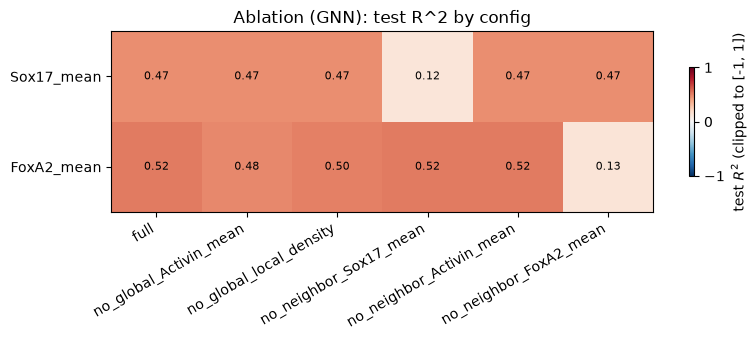

experiment,full,no_global_Activin_mean,no_global_local_density,no_neighbor_Sox17_mean,no_neighbor_Activin_mean,no_neighbor_FoxA2_mean
target,,,,,,
Sox17_mean,0.467334,0.466157,0.465226,0.121874,0.466509,0.467255
FoxA2_mean,0.516297,0.483525,0.503860,0.516206,0.516256,0.128221


<Figure size 640x480 with 0 Axes>

In [5]:
target_cols_by_experiment = {name: BASE_Y_COLS for name in ABLATION_CONFIGS}
comparison = plot_experiment_comparison(
    results, target_cols_by_experiment, title=f'Ablation ({MODEL_TYPE.upper()}): test R^2 by config'
)
plt.gcf().savefig(f'{fig_dir}/ablation_{MODEL_TYPE}_comparison.png', dpi=300, bbox_inches='tight')
display(comparison)

,feature,target,importance_mean,importance_std
0,Activin_mean (global),Sox17_mean,0.001177,0.0
1,Activin_mean (global),FoxA2_mean,0.032771,0.0
2,local_density (global),Sox17_mean,0.002108,0.0
3,local_density (global),FoxA2_mean,0.012437,0.0
4,Sox17_mean (neighbor),Sox17_mean,0.345459,0.0
5,Sox17_mean (neighbor),FoxA2_mean,0.000091,0.0
6,Activin_mean (neighbor),Sox17_mean,0.000825,0.0
7,Activin_mean (neighbor),FoxA2_mean,0.000041,0.0
8,FoxA2_mean (neighbor),Sox17_mean,0.000078,0.0
9,FoxA2_mean (neighbor),FoxA2_mean,0.388076,0.0


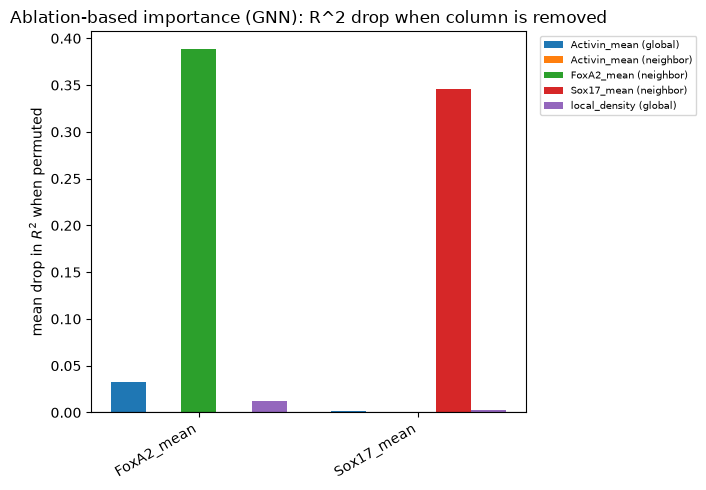

In [6]:
# Derived importance = R^2 drop vs. the 'full' model when that ONE column is removed --
# higher means that column (global or neighbor) contributes more to predicting that target.
full_r2 = results['full']['r2']['R2']
rows = []
for name, res in results.items():
    if name == 'full':
        continue
    if name.startswith('no_global_'):
        feature, kind = name[len('no_global_'):], 'global'
    else:
        feature, kind = name[len('no_neighbor_'):], 'neighbor'
    for target in BASE_Y_COLS:
        drop = full_r2[target] - res['r2']['R2'][target]
        rows.append({'feature': f'{feature} ({kind})', 'target': target, 'importance_mean': drop, 'importance_std': 0.0})

importance_df = pd.DataFrame(rows)
display(importance_df)

fig = plot_feature_importance_by_target(
    importance_df, title=f'Ablation-based importance ({MODEL_TYPE.upper()}): R^2 drop when column is removed'
)
fig.savefig(f'{fig_dir}/ablation_{MODEL_TYPE}_importance.png', dpi=300, bbox_inches='tight')
plt.show()